dict_keys(['__header__', '__version__', '__globals__', 'images', 'automaticFluidDME', 'manualFluid1', 'manualFluid2', 'automaticLayersDME', 'automaticLayersNormal', 'manualLayers1', 'manualLayers2'])
(8, 768, 61)


(np.float64(-0.5), np.float64(767.5), np.float64(495.5), np.float64(-0.5))

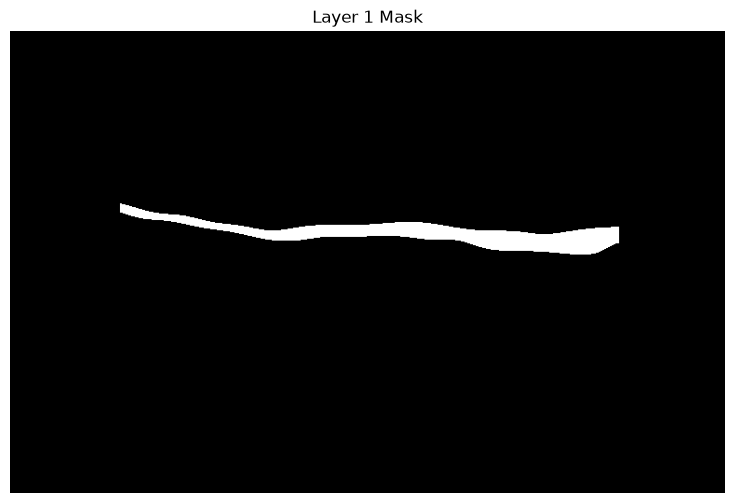

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat

scan = 10
data = loadmat("../datasets/duke/2015_BOE_Chiu/Subject_01.mat")
images = data["images"]
image = images[:, :, scan]

print(data.keys())
layers = data["manualLayers1"]

print(layers.shape)

mask = np.zeros((496,768), dtype=np.uint8)

for x in range(768):

    top = layers[0, x, scan]
    bottom = layers[1, x, scan]

    if np.isnan(top) or np.isnan(bottom):
        continue

    top = int(round(top))
    bottom = int(round(bottom))

    mask[top:bottom, x] = 1

plt.figure(figsize=(12,6))

plt.imshow(mask, cmap="gray")

plt.title("Layer 1 Mask")
plt.axis("off")

(np.float64(-0.5), np.float64(767.5), np.float64(495.5), np.float64(-0.5))

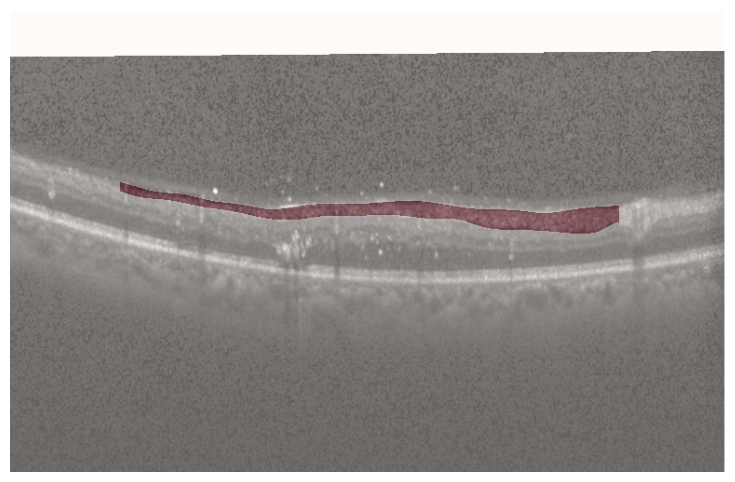

In [25]:
plt.figure(figsize=(12,6))

plt.imshow(image, cmap="gray")

plt.imshow(mask,
           alpha=0.4,
           cmap="Reds")

plt.axis("off")

## Overlay the first mask on the original image
This step visualizes the generated binary mask directly over the OCT scan to confirm the region looks correct.

(np.float64(-0.5), np.float64(767.5), np.float64(495.5), np.float64(-0.5))

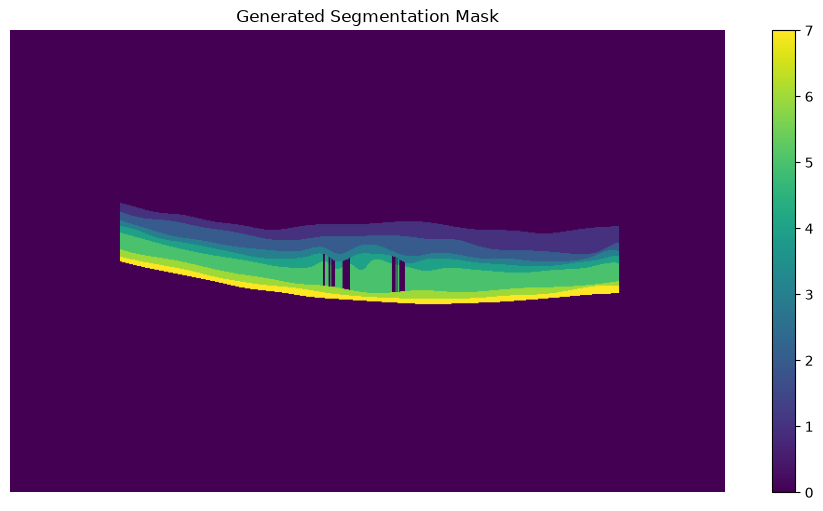

In [26]:
scan = 10

image = images[:, :, scan]

mask = np.zeros(image.shape, dtype=np.uint8)

for x in range(image.shape[1]):

    for region in range(7):

        top = layers[region, x, scan]
        bottom = layers[region + 1, x, scan]

        if np.isnan(top) or np.isnan(bottom):
            continue

        top = int(round(top))
        bottom = int(round(bottom))

        mask[top:bottom, x] = region + 1
plt.figure(figsize=(12,6))

plt.imshow(mask)

plt.colorbar()

plt.title("Generated Segmentation Mask")
plt.axis("off")

## Build a multi-region segmentation mask
This cell expands the simple binary mask into a multi-label mask that separates the retinal regions between consecutive layer boundaries.

(np.float64(-0.5), np.float64(767.5), np.float64(495.5), np.float64(-0.5))

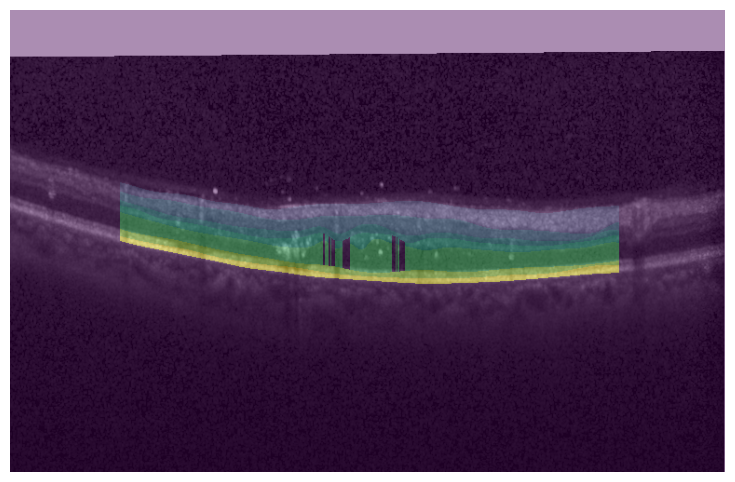

In [27]:
plt.figure(figsize=(12,6))

plt.imshow(image, cmap="gray")

plt.imshow(mask, alpha=0.45)

plt.axis("off")

## Visualize the segmentation result
This cell displays the full segmentation map over the original scan so the region boundaries are easier to inspect.

In [28]:
print(np.unique(mask))

[0 1 2 3 4 5 6 7]


## Inspect the mask values
This short check shows the unique labels present in the segmentation mask, which helps confirm the mask was generated as expected.

(np.float64(-0.5), np.float64(767.5), np.float64(495.5), np.float64(-0.5))

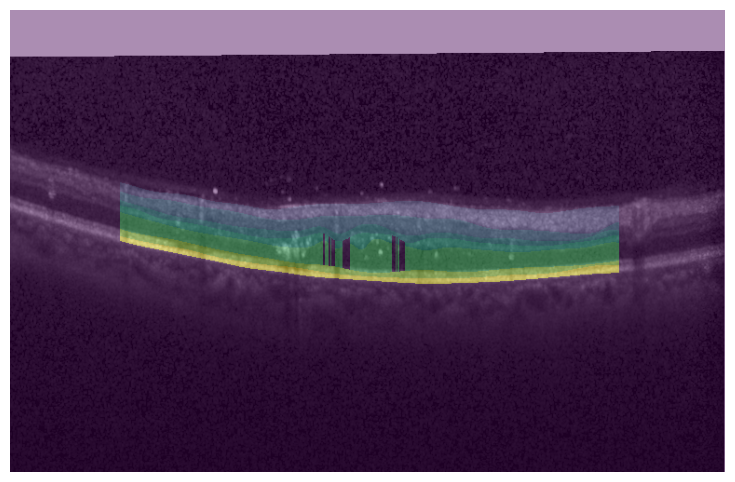

In [30]:
from src.masks import generate_mask

scan = 10

mask = generate_mask(
    layers[:, :, scan],
    image.shape
)

plt.figure(figsize=(12,6))

plt.imshow(image, cmap="gray")

plt.imshow(mask, alpha=0.45)

plt.axis("off")

## Compare with the reusable helper function
This cell uses the project’s mask-generation helper to verify that the manual approach matches the function-based implementation.